## Denoising Diffusion Probabilistic Models (DDPM)

- DDPM applies incremental updates(**Chain of Conversion**) in **Encoder-Decoder** architecture, in which the sequence of Encoder steps is called **Forward process** and the sequence of Decoder steps is called **Reverse Process**. 
- In DDPM, we make *Noise* in the forward process and remove *Noise* in the backward process.

#### The Core Idea of DDPM:-
- **Forward Process**:-  This is a fixed process where we gradually add a small amount of *Gaussian Noise* to an image over a series of timesteps. This process is a **Markov Chain** , meaning the state at any given timestep only depends on the immediately preceding one.As we progress through the timesteps, the image becomes increasingly noisy until it is indistinguishable from pure *Gaussian Noise*.

- **Reverse Process**:-  This is the learned process where the model aims to reverse the *Forward Diffusion*. Starting with pure noise, the model iteratively removes a small amount of noise at each timestep, gradually transforming the noise into a coherent image. This process is also made up as a **Markov Chain**.

![ddpm_3.png](./images/ddpm_3.png)

#### Forward Process
- The forward process is to take a perfectly clear image and gradually add a little bit of random noise at each step, until the image becomes pure noise.

- We control this process over a set number of **timesteps**, labeled from $t = 1\,to\; T $. 
![ddpm.png](./images/ddpm.png)

#### Reverse Process
- The goal of reverse process, denoted by $p_θ$, is to learn the true reverse distribution $q(x_t-1 | x_t)$ to be able to generate a clean image from **noise**. 

- The neural network {often a **U-NET** architecture} is trained to predict the noise that was added to the image at each timestep.

  ![ddpm_2.png](./images/ddpm_2.png)

#### Training Process
- The main goal in DDPM is to train a *neural network* to predict the noise component of a noisy sample $x_t$ at a given timestep *t*. 

- **Sampling**: For each training step, we sample a triplet:
    1. A real image $x_0$ from the true data distribution.
    2. A timestep *t* uniformly from the set of all possible timesteps, {1,..., T}.
    3. A noise vector from a **standard multivariate Gaussian Distribution, *N(0, I)*. 

- **Forward Process**: We generate a single noisy sample $x_t$ using the **Reparameterization Trick** to ensure the process is differentiable.

- **Noise Prediction**: The neural network takes the corrupted sample $x_t$ and the corresponding timestep *t* as input. The network is **conditioned** to allow it to learn a different noise distribution at each step of the diffusion process. The network predicts the noise added at the timestep to the image and outputs this **predicted noise vector**.

- **Loss Calculation**: The loss function is **Mean Squared Error(MSE)**, and it is computed between the **true noise{from Step 1}** and the **noise predicted by the model**.

- **Weight Update**: The network weights are updated using a stochastic optimization algorithm such as **Adam** by backpropagating the gradients of the loss function.

In [1]:
import torch 
import torch.nn as nn 
import torch.nn.functional as F 
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

In [2]:
batch_size = 128
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])
dataset = datasets.CIFAR10(
    "./data",
    train= True,
    transform=transform,
    download=True,
)

loader = DataLoader(dataset, batch_size=128, shuffle = True)

Files already downloaded and verified


- Show some examples of the Dataset

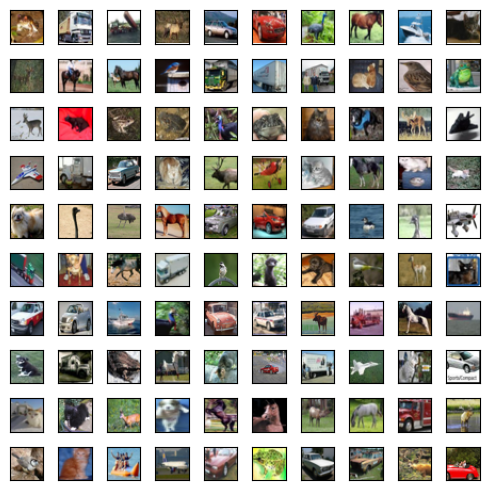

In [3]:
num_row = 10
num_col = 10
fig, axes = plt.subplots(num_row, num_col, figsize = (5,5))
tmp_loader = DataLoader(dataset, batch_size = num_row*num_col, shuffle = False)
for data, _ in tmp_loader:
    for i in range(num_row*num_col):
        img = data[i].numpy()
        img_channel = np.transpose(img, (1,2,0)) #Shape: [C,H,W]---->[H,W,C]
        row = i // num_col
        col = i % num_col
        ax = axes[row, col]
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(img_channel)
    break
plt.tight_layout()
plt.show()

#Delete the temp loader
del tmp_loader
        

## Implement the U-NET

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#### Positional Encoding Block

In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self, base_dim, hidden_dim, output_dim):
        super().__init__()
        
        assert base_dim % 2 == 0,"Embedding Dimension should be EVEN"
        self.timestep_dim = base_dim
        
        self.hidden1 = nn.Linear(in_features=base_dim, out_features=hidden_dim)
        self.hidden2 = nn.Linear(in_features=hidden_dim, out_features=output_dim)
        
    def forward(self, timesteps):
        ''' 
            This function will generate Embedding vectors for Timestep
            
            Input(Args):
                    - timesteps: Randomly picked up timesteps

            Return:
                    - Tensor containing timestep embedding vectors for each timesteps.    
        '''
        
        #Get the 1 / 10000^(2i / dim) which is the denominator for our Sinusoidal Positional Formula
        interval = 1.0 / (10000**(torch.arange(0, self.timestep_dim, 2.0).to(device) / self.timestep_dim))
        
        #Now get {t * interval} which is {t / 10000^(2i / dim)} 
        position = timesteps.type(torch.get_default_dtype())
        radian = position[:, None] * interval[None, :]
        
        #Now compute the Sin of the position sin(t / 10000^(2i / dim))
        sin = torch.sin(radian).unsqueeze(dim = -1) #Shape: [batch_size, timestep_dim/2, 1]
        
        #Similarly compute the Cos of the position cos(t / 10000^(2i / dim))
        cos = torch.cos(radian).unsqueeze(dim = -1) #Shape: [batch_size, timestep_dim/2, 1]

        #Now compute Sinusoidal Positional Encoding 
        posi_encoding = torch.concat((sin, cos), dim = -1) #Shape: [num_timestep, timestep_dim / 2, 2]
        d = posi_encoding.size()[1]
        posi_encoding = posi_encoding.view(-1, d * 2)    #Shape: [num_timestep, timestep_dim]
        
        #Now Project the Positional Encoding through the FeedForward Network
        out = self.hidden1(posi_encoding)
        out = F.silu(out)
        out = self.hidden2(out)
        
        return out
        

![ddpm_4.png](./images/ddpm_4.png)

In [6]:
class ResnetBlock(nn.Module):
    def __init__(self, in_channel, out_channel, num_norm_groups, timestep_embedding_dim):
        super().__init__()
        
        #For Convolution 
        self.conv1 = nn.Conv2d(in_channel, out_channel, kernel_size=3, stride=1, padding="same")
        self.conv2 = nn.Conv2d(out_channel, out_channel, kernel_size=3, stride = 1, padding="same")
        
        #For Normalization
        self.norm1 = nn.GroupNorm(num_groups=num_norm_groups, num_channels=in_channel, eps=1e-06)
        self.norm2 = nn.GroupNorm(num_groups=num_norm_groups, num_channels=out_channel, eps = 1e-06)
        
        #For Timestep Embedding
        self.linear_posi = nn.Linear(timestep_embedding_dim, out_channel)
        
        #For Residual Block
        if in_channel != out_channel:
            self.linear_src = nn.Linear(in_channel, out_channel)
        else:
            self.linear_src = None
            
    
    def forward(self, x, time_emb):
        #Project the Input through one Convolution Layer
        out = self.norm1(x)
        out = F.silu(out)
        out = self.conv1(out)
        
        #Add Timestep Embedding to the Output
        posi = F.silu(time_emb)
        posi = self.linear_posi(posi)
        posi = posi[:, :, None, None]
        out = out + posi
        
        #Add Dropout and Project the output through the last convolution layer
        out = self.norm2(out)
        out = F.silu(out)
        out = F.dropout(out, p=0.1, training=self.training)
        out = self.conv2(out)
        
        #Add Residual Connection
        if self.linear_src is not None:
            x_transpose = x.permute(0,2,3,1) #Shape: [batch, channels, height, width]------>[batch, height, width, channels]
            x_transpose = self.linear_src(x_transpose)
            x_transpose = x_transpose.permute(0,3,1,2)  #Shape: [batch, height, width, channels]------>[batch, channels, height, width]
            out = out + x_transpose
        else:
            out = out + x
        
        return out

#### Attention Block

In [7]:
class AttentionBlock(nn.Module):
    def __init__(self, channel, num_norm_groups):
        super().__init__()
        
        self.norm = nn.GroupNorm(num_groups=num_norm_groups, num_channels=channel, eps=1e-06)
        
        self.Wq = nn.Linear(channel, channel)
        self.Wk = nn.Linear(channel, channel)
        self.Wv = nn.Linear(channel, channel)
        
        self.final_proj = nn.Linear(channel, channel, bias = False)
        
    def forward(self, x):
        channel = x.size(dim = 1)
        height = x.size(dim = 2)
        width = x.size(dim = 3)
        
        out = self.norm(x)
        
        #Reshape: [B, C, H, W]----->[B, H*W, C]
        out = out.permute(0, 2,3,1).view(-1, height*width, channel)
        
        #Get the Q,K,V matrices
        q = self.Wq(out)
        k = self.Wk(out)
        v = self.Wv(out)
        
        #Compute Attention Weights
        attn_scores = torch.einsum("bic,bjc->bij", q, k)
        
        #Scale the Attn_Scores
        attn_scores = attn_scores / channel**0.5
        
        #Compute the Softmax function 
        attn_scores = F.softmax(attn_scores, dim = -1) 
        
        #Apply the Dot Product with Values
        out = torch.einsum("bij,bjc->bic", attn_scores, v)
        
        #Apply the final projection
        out = self.final_proj(out)
        
        #Reshape: [B,H*W,C]----->[B,C,H,W]
        out = out.view(-1, height, width, channel).permute(0, 3, 1, 2)
        
        #Add Residual Connection
        out = out + x
        
        return out
        

#### ResNet & Attention Block

In [8]:
class ResnetAttention(nn.Module):
    def __init__(self, in_channel, out_channel, num_norm_groups, timestep_embedding_dim):
        super().__init__()
        
        self.resnet = ResnetBlock(in_channel, out_channel, num_norm_groups, timestep_embedding_dim)
        self.attention = AttentionBlock(out_channel, num_norm_groups)
        
    def forward(self, x, t_emb):
        out = self.resnet(x, t_emb)
        out = self.attention(out)
        
        return out

In [9]:
class DownSample(nn.Module):
    def __init__(self, channel):
        super().__init__()
        self.conv = nn.Conv2d(channel, channel, kernel_size=3, stride=2, padding=1) #Size will get half 
    
    def forward(self, x):
        return self.conv(x)
        

class UpSample(nn.Module):
    def __init__(self, channel):
        super().__init__()
        self.conv = nn.Conv2d(channel, channel, kernel_size=3, stride=1, padding="same")
    
    def forward(self, x):
        out = F.interpolate(x, scale_factor=2, mode="nearest")
        out = self.conv(out)
        return out

    - U-NET NETWORK ARCHITECTURE

In [10]:
class UNET(nn.Module):
    def __init__(self,source_channel, unet_base_channel, num_norm_groups):
        super().__init__()
        
        #Get the Positional Encoding
        self.pos_enc = PositionalEncoding(base_dim = unet_base_channel, hidden_dim=unet_base_channel*2, output_dim=unet_base_channel*4)
        
        #DownSample Path
        self.down_conv = nn.Conv2d(source_channel, unet_base_channel, kernel_size=3, stride=1, padding="same")
        
        self.down = nn.ModuleList(
            [   
                #--------1 Layer-----------
                ResnetBlock(in_channel=unet_base_channel, out_channel=unet_base_channel, num_norm_groups=num_norm_groups, timestep_embedding_dim=unet_base_channel*4),
                ResnetBlock(in_channel=unet_base_channel, out_channel=unet_base_channel, num_norm_groups=num_norm_groups, timestep_embedding_dim=unet_base_channel*4),
                DownSample(channel=unet_base_channel),
                
                #---------2 Layer------------
                ResnetAttention(in_channel=unet_base_channel, out_channel=unet_base_channel*2, num_norm_groups=num_norm_groups, timestep_embedding_dim=unet_base_channel*4),
                ResnetAttention(in_channel=unet_base_channel*2, out_channel=unet_base_channel*2, num_norm_groups=num_norm_groups, timestep_embedding_dim=unet_base_channel*4,),
                DownSample(unet_base_channel*2),
            
                #----------3 Layer------------
                ResnetBlock(in_channel=unet_base_channel*2, out_channel=unet_base_channel*2, num_norm_groups=num_norm_groups, timestep_embedding_dim=unet_base_channel*4),
                ResnetBlock(in_channel=unet_base_channel*2, out_channel=unet_base_channel*2, num_norm_groups=num_norm_groups, timestep_embedding_dim=unet_base_channel*4),
                DownSample(channel=unet_base_channel*2),
                
                #-----------4 Layer------------
                ResnetBlock(in_channel=unet_base_channel*2, out_channel=unet_base_channel*2, num_norm_groups=num_norm_groups, timestep_embedding_dim=unet_base_channel*4),
                ResnetBlock(in_channel=unet_base_channel*2, out_channel=unet_base_channel*2, num_norm_groups=num_norm_groups, timestep_embedding_dim=unet_base_channel*4),
            ]
        )
        
        self.middle = nn.ModuleList(
            [
                #----------1 Layer-----------
                ResnetBlock(in_channel=unet_base_channel*2, out_channel=unet_base_channel*2, num_norm_groups=num_norm_groups, timestep_embedding_dim=unet_base_channel*4),
                AttentionBlock(channel=unet_base_channel*2, num_norm_groups=num_norm_groups),
                ResnetBlock(in_channel=unet_base_channel*2, out_channel=unet_base_channel*2, num_norm_groups=num_norm_groups, timestep_embedding_dim=unet_base_channel*4),
            ]
        )
        
        self.up = nn.ModuleList(
            [
               #-----------1 Layer-------------
               ResnetBlock(in_channel=unet_base_channel*4, out_channel=unet_base_channel*2, num_norm_groups=num_norm_groups, timestep_embedding_dim=unet_base_channel*4),
               ResnetBlock(in_channel=unet_base_channel*4, out_channel=unet_base_channel*2, num_norm_groups=num_norm_groups, timestep_embedding_dim=unet_base_channel*4),
               ResnetBlock(in_channel=unet_base_channel*4, out_channel=unet_base_channel*2, num_norm_groups=num_norm_groups, timestep_embedding_dim=unet_base_channel*4),
               UpSample(channel=unet_base_channel*2),
               
               #------------2 Layer------------
               ResnetBlock(in_channel=unet_base_channel*4, out_channel=unet_base_channel*2, num_norm_groups=num_norm_groups, timestep_embedding_dim=unet_base_channel*4),
               ResnetBlock(in_channel=unet_base_channel*4, out_channel=unet_base_channel*2, num_norm_groups=num_norm_groups, timestep_embedding_dim=unet_base_channel*4),
               ResnetBlock(in_channel=unet_base_channel*4, out_channel=unet_base_channel*2, num_norm_groups=num_norm_groups, timestep_embedding_dim=unet_base_channel*4),
               UpSample(channel = unet_base_channel*2),
               
               #---------3 Layer------------
               ResnetAttention(in_channel=unet_base_channel*4, out_channel=unet_base_channel*2, num_norm_groups=num_norm_groups, timestep_embedding_dim=unet_base_channel*4),
               ResnetAttention(in_channel=unet_base_channel*4, out_channel=unet_base_channel*2, num_norm_groups=num_norm_groups, timestep_embedding_dim=unet_base_channel*4),
               ResnetAttention(in_channel=unet_base_channel*3, out_channel=unet_base_channel*2, num_norm_groups=num_norm_groups, timestep_embedding_dim=unet_base_channel*4),
               UpSample(channel = unet_base_channel*2),
               
               #----------4 Layer-----------
               ResnetBlock(in_channel=unet_base_channel*3, out_channel=unet_base_channel, num_norm_groups=num_norm_groups, timestep_embedding_dim=unet_base_channel*4),
               ResnetBlock(in_channel=unet_base_channel*2, out_channel=unet_base_channel, num_norm_groups=num_norm_groups, timestep_embedding_dim=unet_base_channel*4),
               ResnetBlock(in_channel=unet_base_channel*2, out_channel=unet_base_channel, num_norm_groups=num_norm_groups, timestep_embedding_dim=unet_base_channel*4),   
            ]
        )
        
        #Normalization for UNET
        self.norm = nn.GroupNorm(num_channels=unet_base_channel, num_groups=num_norm_groups, eps=1e-06)
        
        #Final Convolution to get the output shape as same as the input shape
        self.final_conv = nn.Conv2d(unet_base_channel, source_channel, kernel_size=3, stride=1, padding="same")
    
    
    def forward(self, x, t):
        ''' 
            Input(Args):
                1. x: Tensor which contains the Image having  Gaussian Noise.
                2. t: Timestep
        '''
        
        buffer = []
        
        #Get timestep Embeddings
        time_embs = self.pos_enc(t)
        
        #============Top-To-Down=============
        out = self.down_conv(x)
        buffer.append(out)
        for block in self.down:
            if isinstance(block, ResnetBlock):
                out = block(out, time_embs)
            elif isinstance(block, ResnetAttention):
                out = block(out, time_embs)
            elif isinstance(block, DownSample):
                out = block(out)
            else:
                raise Exception("Unkown Block")
            buffer.append(out)
        
        #==============Middle======================
        for block in self.middle:
            if isinstance(block, ResnetBlock):
                out = block(out, time_embs)
            elif isinstance(block, AttentionBlock):
                out = block(out)
            else:
                raise Exception("Unkown Block")
            
            
        #==============Down-To-Top==================
        for block in self.up:
            if isinstance(block, ResnetBlock):
                buf = buffer.pop()
                #Add Residual Connection
                out = torch.cat((out, buf), dim = 1)
                out = block(out, time_embs)
            elif isinstance(block, ResnetAttention):
                buf = buffer.pop()
                #Add Residual Connection
                out = torch.cat((out, buf), dim = 1)
                out = block(out, time_embs)
            elif isinstance(block, UpSample):
                out = block(out)
            else:
                raise Exception("Unkown Block")
        
        #===============Apply Final Convolution===========
        out = self.norm(out)
        out = F.silu(out)
        out = self.final_conv(out)
        
        assert not buffer
        
        return out


In [11]:
model = UNET(source_channel=3, unet_base_channel=128, num_norm_groups=32).to(device)
model

UNET(
  (pos_enc): PositionalEncoding(
    (hidden1): Linear(in_features=128, out_features=256, bias=True)
    (hidden2): Linear(in_features=256, out_features=512, bias=True)
  )
  (down_conv): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (down): ModuleList(
    (0-1): 2 x ResnetBlock(
      (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
      (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
      (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
      (linear_posi): Linear(in_features=512, out_features=128, bias=True)
    )
    (2): DownSample(
      (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    )
    (3): ResnetAttention(
      (resnet): ResnetBlock(
        (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
        (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
    

In [12]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Params:{total_params:,}")
print(f"Trainable Params: {trainable_params:,}")

Total Params:35,580,675
Trainable Params: 35,580,675


- Model Training
    1. Initialize **T** and  **alpha_t**
    2. Pick up **x_0** in training set.
    3. Pick up timestep **t**
    4. Generate the seed of noise EPSILON, such as EPSILON belongs to Gaussian~Noise
    5. Compute x_t
    6. Take the Gradient Descent Step
    7. Repeat 2-6 until convergence.

- WandB Initiaization

In [ ]:
import wandb
from torchvision.utils import make_grid

wandb.init(
    project = "ddpm-training",
    config = {
        "learning_rate": 2e-4,
        "epochs": 100,
        "timesteps":1000,
        "batch_size":loader.batch_size
    }
)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr = 2e-4, eps = 1e-08)
scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor= 1.0/5000, end_factor = 1.0, total_iters = 5000)

#------------Noise Schedule-----------------------
T = 1000
alphas = torch.linspace(start = 0.9999, end = 0.99, steps = T, dtype = torch.float64).to(device)
alphas_bars = torch.cumprod(alphas, dim = 0)
sqrt_alpha_bars_t = torch.sqrt(alphas_bars)
sqrt_one_minus_alpha_bars_t = torch.sqrt(1.0 - alphas_bars)

#Precompute the Betas for Reverse Diffusion
betas = 1 - alphas
sqrt_reciprocal_alphas = torch.sqrt(1.0 / alphas)
posterior_variance = betas * (1.0 - alphas_bars[:-1].clone().detach()) / (1.0 - alphas_bars[1:].clone().detach())
posterior_variance = torch.car([posterior_variance, torch.tensor([1e-8], device=device)])

#Sampling Function
@torch.no_grad()
def sample_images(model, sample_size = 8):
    model.eval()
    x_t = torch.randn(sample_size, 3, 64, 64, device = device)
    for t in reversed(range(T)):
        t_batch = torch.full((sample_size,), t, device = device, dtype = torch.long)
        eps_theta = model(x_t, t_batch)
        
        #Education for x_t{t-1}
        sqrt_reciprocal_alpha_t = sqrt_reciprocal_alphas[t]
        beta_t = betas[t]
        sqrt_one_minus_alpha_bar_t = sqrt_one_minus_alpha_bars_t[t]
        
        #Predict x_0
        x_0_pred = (x_t - sqrt_one_minus_alpha_bar_t * eps_theta) 

#--------------Training Loop-------------------------
num_epochs = 100
for epoch_idx in range(num_epochs):
    epoch_loss = []
    for batch_idx, (data, _) in enumerate(loader):
        model.train()
        optimizer.zero_grad()
        
        #Get the input at time t = 0
        x_0 = data.to(device)
        
        #Pick random_timesteps 
        b = x_0.size(dim = 0)
        t = torch.randint(T, (b,)).to(device)
        
        #Generate the Noise,Epsilon
        eps = torch.randn_like(x_0).to(device)
        
        #Compute x_t = sqrt(alpha_bar at timestep t)x_0 + sqrt(1 - alpha_bar) epsilon
        x_t = sqrt_alpha_bars_t[t][:,None,None,None].float() * x_0 + (sqrt_one_minus_alpha_bars_t[t][:, None,None,None].float() * eps)
        
        #Get Loss and apply Gradient(Update)
        model_output = model(x_t, t)
        loss = F.mse_loss(model_output, eps, reduction = "mean")
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        #Log the Training Results
        epoch_loss.append(loss.item())
        print(f"Epoch:[{epoch_idx+1}] (Iter:{batch_idx+1}) --> Loss: [{loss:5.4f}]")
        
    #Finalize Epoch(save log and checkpoint)
    epoch_avg_loss = sum(epoch_loss)/len(epoch_loss)
    print(f"Epoch:[{epoch_idx+1}] (Iter:[{batch_idx+1}])---> Loss:[{epoch_avg_loss:5.4f}]")
    checkpoint = {"model_state_dict": model.state_dict(),
                  "optimizer_state_dict": optimizer.state_dict(),
                  "loss": loss,
                  "epoch": epoch_idx+1}
    
    torch.save(checkpoint,f"./saves/checkpoint_{epoch_idx+1}.pt")
    

print("==============Training Completed=======================")
wandb.finish()
    